### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 2
### Due: Monday, Sep. 21 at 11.59pm CST
---

## Problem 1

This question is about Monte Carlo integration. A standard Gaussian integral takes the form 

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

1) Write down the usual form of a Gaussian distribution with $\mu=0$ and $\sigma=\sigma$ that is normalized between $\infty$ and $+\infty$. What is the corresponding form of a half-Gaussian distribution between $0$ and $+\infty$? (Remember that the half-Gaussian distribution must be normalized such that it integrates to one.)

2) Manipulate the above equation such that you can write the left hand side in terms of a normalized half-Gaussian distribution. 

3) Draw $N=10^5$ samples from a $\sigma=3$ normal distribution, mask the samples such that only positive values are accepted, then perform Monte Carlo integration using your equation in (2). Confirm that this *approximately* matches the value computed from the right hand side of the equation. If you don't get approximately matching values then you may have forgotten normalization factors for the Gaussian, or constant factors from translating a normalized Gaussian to a half-Gaussian.

4) Repeat (3) for $N=[10^2,10^3,10^4]$, computing the integral using $100$ different batches of random samples for each $N$. Record all calculated values at all $N$. 

5) Make a plot that shows $\log_{10}N$ along the $x$-axis and the spread between the maximum and minimum Monte Carlo integral values that you get at each $N$ on the $y$-axis. (Note: matplotlib's `fill_between` command is useful for this). Plot a horizontal line on the same figure to show the precise mathematical value. You should see that Monte Carlo integration results in less numerical spread as $N$ gets larger.

### Solution

Monte Carlo integral: 162.46932281863545
Exact integral: 162
100
100
100


<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

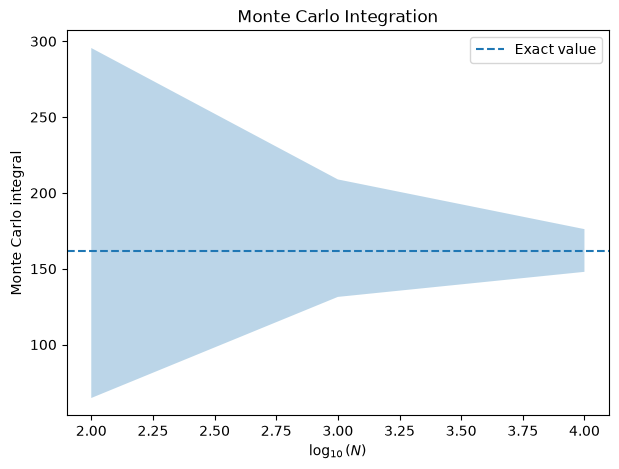

In [3]:
import numpy as np


N = 10**5
# Set the number of random samples to 100,000.


sigma = 3
# Set the standard deviation of the normal distribution to 3.


samples = np.random.normal(0, sigma, N)
# Generate 100,000 samples from a normal distribution.
#
# The arguments are:
#   0      = mean (mu)
#   sigma  = standard deviation
#   N      = number of samples
#
# Therefore, we are sampling from N(0, 3).


positive_samples = samples[samples > 0]
# Create a mask that selects only samples greater than zero.
#
# This gives us the positive half of the Gaussian distribution.


mean_x3 = np.mean(positive_samples**3)
# Cube every positive sample and then take their average.
#
# This estimates the half-Gaussian expectation value:
#
# <x^3> = (1/N) sum(x_i^3)


integral = (np.sqrt(2 * np.pi) * sigma / 2) * mean_x3
# Multiply the Monte Carlo average by the normalization factor
# derived in Part 2:
#
# sqrt(2*pi)*sigma / 2


exact = 2 * sigma**4
# Calculate the exact answer from the right-hand side
# of the original equation:
#
# integral = 2*sigma^4


print("Monte Carlo integral:", integral)
print("Exact integral:", exact)
N_values = [10**2, 10**3, 10**4]
#The three sample sizes:
# 10^2 = 100
# 10^3 = 1,000
# 10^4 = 10,000


n_batches = 100
# We need 100 independent Monte Carlo calculations for each sample size.


results = {}
# Create an empty dictionary.
# We will store the results for each N here.


for N in N_values:
    # This loop goes through:
    # N = 100
    # N = 1,000
    # N = 10,000


    integral_values = []
    # Create an empty list to store the 100
    # Monte Carlo results for this particular N.


    for i in range(n_batches):
        # Repeat the calculation 100 times.


        samples = np.random.normal(0, sigma, N)
        # Generate N samples from the normal distribution
        # with mean 0 and standard deviation 3.


        positive_samples = samples[samples > 0]
        # Keep only the positive samples.


        mean_x3 = np.mean(positive_samples**3)
        # Cube the positive samples and calculate their mean.


        integral = (np.sqrt(2 * np.pi) * sigma / 2) * mean_x3
        # Apply the normalization factor from Part 2
        # to convert the mean into an estimate of the integral.


        integral_values.append(integral)
        # Save this particular Monte Carlo result
        # in our list of 100 results.


    results[N] = integral_values
    # Save all 100 results under the appropriate value of N.

print(len(results[100]))
print(len(results[1000]))
print(len(results[10000]))

import matplotlib.pyplot as plt
minimums = []
# Create an empty list for the minimum value at each N.


maximums = []
# Create an empty list for the maximum value at each N.


for N in N_values:
    # Go through N = 100, 1,000, and 10,000.


    minimums.append(np.min(results[N]))
    # Find the smallest Monte Carlo result among the 100 batches for this N.


    maximums.append(np.max(results[N]))
    # Find the largest Monte Carlo result among the 100 batches for this N.

    plt.figure(figsize=(7, 5))



plt.fill_between(
    np.log10(N_values),
    minimums,
    maximums,
    alpha=0.3
)
# Shade the region between the minimum and maximum Monte Carlo values
# np.log10(N_values) gives:
#   log10(100)    = 2
#   log10(1000)   = 3
#   log10(10000)  = 4

exact = 2 * sigma**4
# Calculate the exact mathematical value.
# For sigma = 3, this is 162.


plt.axhline(
    exact,
    linestyle='--',
    label='Exact value'
)

plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel('Monte Carlo integral')
plt.title('Monte Carlo Integration')
plt.legend()
plt.show()

## Problem 2

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. Access the `ppf` property (percent point function) and use *inverse transform sampling* of the cdf to draw $10^4$ random samples, and make a histogram of these. Overplot the pdf from (1). These should match.

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian object from (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

Random draws: [ 88.28239882 116.57723065 117.20444261 105.02764064 124.77942943
 117.73119473 102.9587641   90.06536749  88.23236442  90.14137757]
PDF at IQ = 145: 0.0002954565607958672


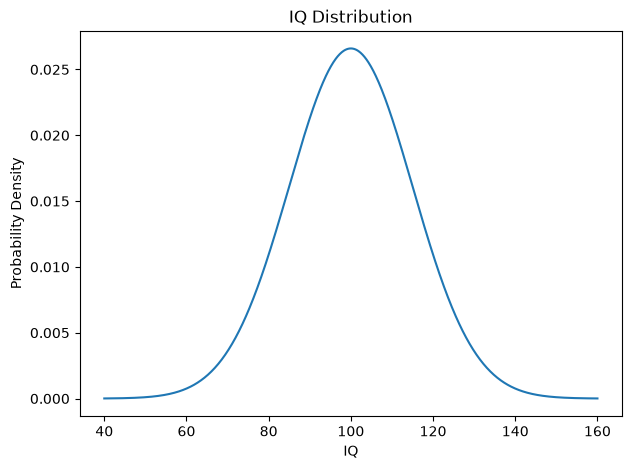

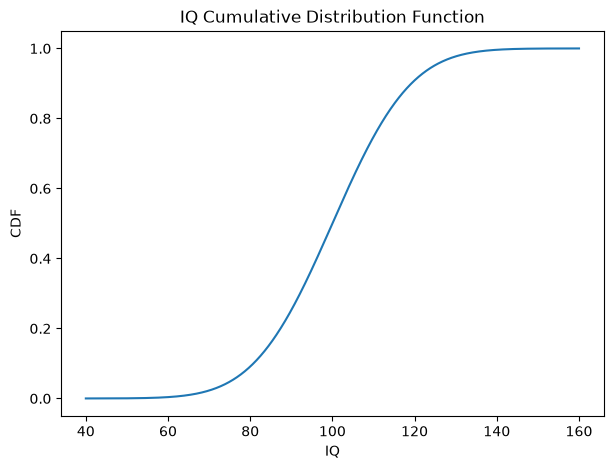

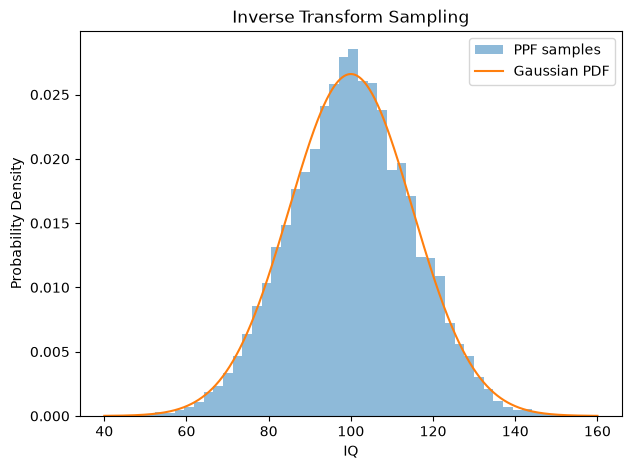

Fraction with IQ > 145: 0.0013498980316301035
IQ for one in a million: 171.3013646322563


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

# Create a Gaussian distribution with mean 100 and standard deviation of 15
distIQ = scipy.stats.norm(100, 15)

# Draw 10 random IQ values from this distribution
draws = distIQ.rvs(10)

# Calculate the probability density at IQ = 145
pdf_145 = distIQ.pdf(145)

print("Random draws:", draws)
print("PDF at IQ = 145:", pdf_145)

# Create an x-axis covering the range of IQ values we want to display
xgrid = np.linspace(40, 160, 1000)

# Calculate the Gaussian PDF at each x value
pdf = distIQ.pdf(xgrid)

plt.figure(figsize=(7, 5))
plt.plot(xgrid, pdf)
plt.xlabel("IQ")
plt.ylabel("Probability Density")
plt.title("IQ Distribution")
plt.show()

# Calculate the cumulative probability at every point in our x-grid
cdf = distIQ.cdf(xgrid)

plt.figure(figsize=(7, 5))
plt.plot(xgrid, cdf)
plt.xlabel("IQ")
plt.ylabel("CDF")
plt.title("IQ Cumulative Distribution Function")
plt.show()


# Generate 10,000 uniformly distributed random numbers between 0 and 1
u = np.random.uniform(0, 1, 10**4)

# Use the inverse CDF (PPF) to transform the uniform samples
# into samples from the IQ Gaussian distribution
x_sample = distIQ.ppf(u)

# Plot the samples as a normalized histogram
plt.figure(figsize=(7, 5))
plt.hist(x_sample, bins=50, density=True, alpha=0.5, label="PPF samples")

# Overplot the original Gaussian PDF for comparison
plt.plot(xgrid, pdf, label="Gaussian PDF")

plt.xlabel("IQ")
plt.ylabel("Probability Density")
plt.title("Inverse Transform Sampling")
plt.legend()
plt.show()


# Calculate the probability of having IQ greater than 145
fraction_above_145 = 1 - distIQ.cdf(145)

print("Fraction with IQ > 145:", fraction_above_145)


# One in a million means only 1/1,000,000 of the
# population is above this IQ.
one_in_million = 1 / 10**6

# Therefore, 0.999999 of the distribution is below this IQ.
cdf_value = 1 - one_in_million

# Use the PPF (inverse CDF) to find the corresponding IQ
iq_one_in_million = distIQ.ppf(cdf_value)

print("IQ for one in a million:", iq_one_in_million)




## Problem 3

This question is about Poisson distributions. A famous early application was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898. Let's take a short look at the kind of data he analyzed.

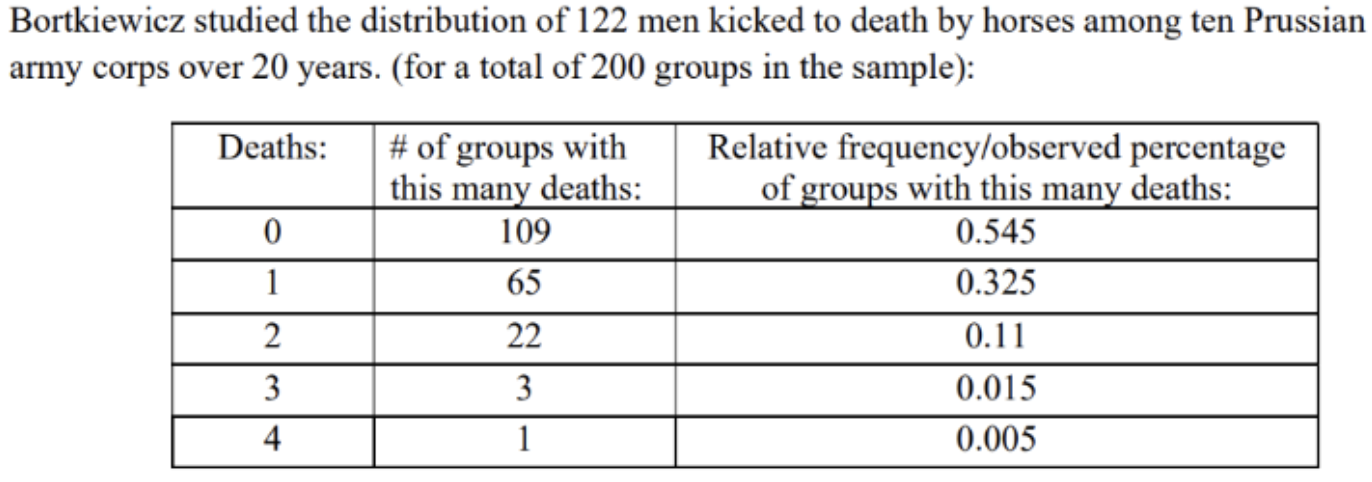

The data essentially consist of 200 total years of Prussian army corps information (i.e. ten army corps over 20 years).

1) Make a plot of the first and third columns of this data.

2) Plot a few Poisson distributions on top that are characterized by different $\mu$ values that might be reasonable guesses for how the data is distributed.

3) We'll come to model fitting next week, but for now use the descriptive sample statistics that you can calculate from this data to deduce the $\mu$ of the modeled Poisson distribution, e.g. the mean, std, median, mode, skewness, and kurtosis, where relevant. Do this however you like, but note that with the data in the table you won't just be able to get a sample mean, since these are tabulated densities, not samples. 

*Hint: use a weighted mean, or alternatively make a dataset that has the numbers 0,1,2,3,4 in agreement with their frequency in the table.*

4) Plot the Poisson distribution with the $\mu$ found in (3) alongside the data.

### Solution

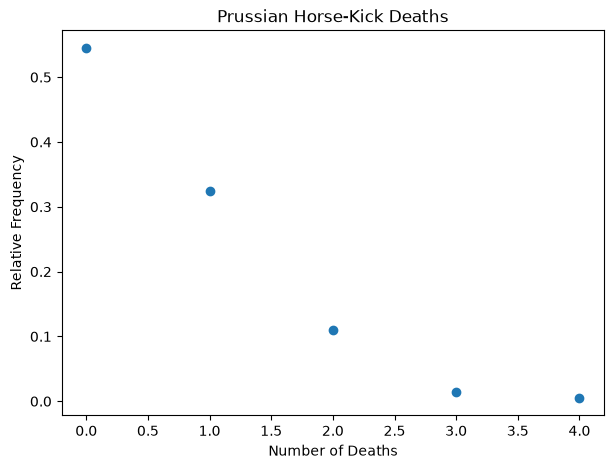

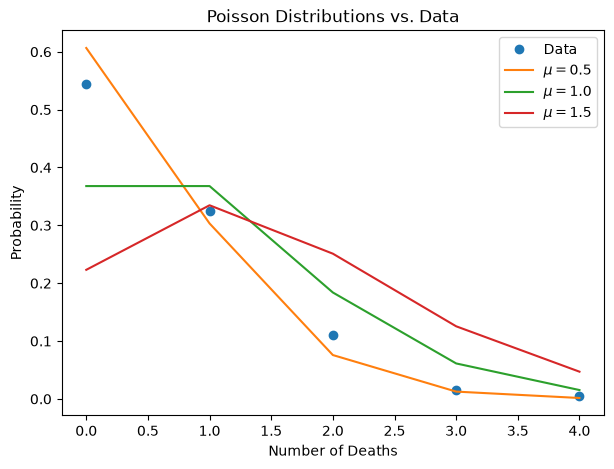

Mean: 0.61
Standard deviation: 0.7796794213008319
Median: 0.0
Mode: 0
Skewness: 1.245997823097657
Kurtosis: 1.4470478232796067
Weighted mean: 0.61


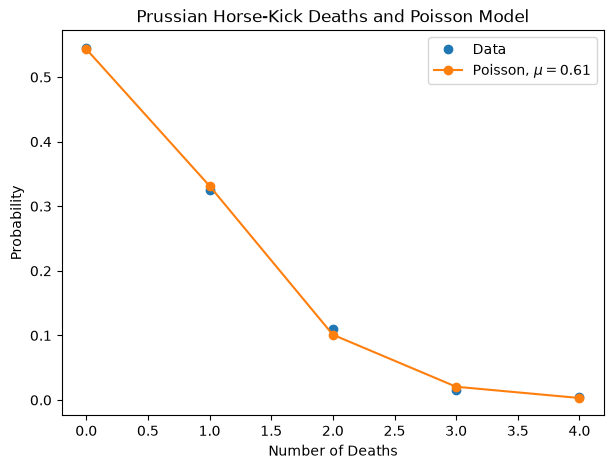

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

deaths = np.array([0, 1, 2, 3, 4])
frequency = np.array([0.545, 0.325, 0.11, 0.015, 0.005])
# Store the number of deaths and their observed relative frequencies

plt.figure(figsize=(7, 5))
plt.plot(deaths, frequency, 'o')
plt.xlabel('Number of Deaths')
plt.ylabel('Relative Frequency')
plt.title('Prussian Horse-Kick Deaths')
plt.show()


mu_values = [0.5, 1.0, 1.5]
# Try several possible values of the Poisson mean μ

k = np.arange(0, 5)
# These are the possible numbers of deaths shown in the table

plt.figure(figsize=(7, 5))

plt.plot(deaths, frequency, 'o', label='Data')

for mu in mu_values:
    poisson_dist = scipy.stats.poisson(mu)
    # Create a Poisson distribution using the current value of μ
    
    plt.plot(k, poisson_dist.pmf(k), 
             label=r'$\mu=$' + str(mu))
    # Calculate and plot the probability for each possible number of deaths

plt.xlabel('Number of Deaths')
plt.ylabel('Probability')
plt.title('Poisson Distributions vs. Data')
plt.legend()
plt.show()


data = np.repeat(deaths, [109, 65, 22, 3, 1])
# Reconstruct the 200 individual observations using the frequencies from the table

mean = np.mean(data)
# Calculate the sample mean, which is the Poisson estimate of μ

std = np.std(data)
median = np.median(data)
mode = scipy.stats.mode(data, keepdims=False).mode
skewness = scipy.stats.skew(data)
kurtosis = scipy.stats.kurtosis(data)

print("Mean:", mean)
print("Standard deviation:", std)
print("Median:", median)
print("Mode:", mode)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

weighted_mean = np.average(deaths, weights=[109, 65, 22, 3, 1])
# Calculate the mean directly from the tabulated frequencies

print("Weighted mean:", weighted_mean)

mu = weighted_mean
# For a Poisson distribution, μ is equal to the mean of the distribution

poisson_dist = scipy.stats.poisson(mu)

k = np.arange(0, 5)
poisson_values = poisson_dist.pmf(k)
# Calculate the Poisson probabilities using the estimated μ

plt.figure(figsize=(7, 5))
plt.plot(deaths, frequency, 'o', label='Data')
plt.plot(k, poisson_values, 'o-', label=r'Poisson, $\mu=0.61$')
# Plot the observed data and the Poisson model together

plt.xlabel('Number of Deaths')
plt.ylabel('Probability')
plt.title('Prussian Horse-Kick Deaths and Poisson Model')
plt.legend()
plt.show()